In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Dataset


In [ ]:
!mkdir -p /content/drive/MyDrive/imagenet_val

In [ ]:
!wget -c "https://www.image-net.org/data/ILSVRC/2012/ILSVRC2012_img_val.tar" -O /content/drive/MyDrive/imagenet_val/ILSVRC2012_img_val.tar

--2026-04-15 16:39:21--  https://www.image-net.org/data/ILSVRC/2012/ILSVRC2012_img_val.tar
Resolving www.image-net.org (www.image-net.org)... 171.64.68.16
Connecting to www.image-net.org (www.image-net.org)|171.64.68.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6744924160 (6.3G) [application/x-tar]
Saving to: ‘/content/drive/MyDrive/imagenet_val/ILSVRC2012_img_val.tar’

/content/drive/MyDr 100%[===================>]   6.28G  3.09MB/s    in 44m 4s  

2026-04-15 17:23:26 (2.43 MB/s) - ‘/content/drive/MyDrive/imagenet_val/ILSVRC2012_img_val.tar’ saved [6744924160/6744924160]



In [ ]:
!tar -xvf /content/drive/MyDrive/imagenet_val/ILSVRC2012_img_val.tar \
     -C /content/drive/MyDrive/imagenet_val/

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
ILSVRC2012_val_00049867.JPEG
ILSVRC2012_val_00049494.JPEG
ILSVRC2012_val_00048672.JPEG
ILSVRC2012_val_00048308.JPEG
ILSVRC2012_val_00047912.JPEG
ILSVRC2012_val_00045841.JPEG
ILSVRC2012_val_00044931.JPEG
ILSVRC2012_val_00044439.JPEG
ILSVRC2012_val_00043527.JPEG
ILSVRC2012_val_00042653.JPEG
ILSVRC2012_val_00042377.JPEG
ILSVRC2012_val_00041405.JPEG
ILSVRC2012_val_00040366.JPEG
ILSVRC2012_val_00035524.JPEG
ILSVRC2012_val_00033710.JPEG
ILSVRC2012_val_00031038.JPEG
ILSVRC2012_val_00030167.JPEG
ILSVRC2012_val_00024859.JPEG
ILSVRC2012_val_00024401.JPEG
ILSVRC2012_val_00023858.JPEG
ILSVRC2012_val_00023793.JPEG
ILSVRC2012_val_00022999.JPEG
ILSVRC2012_val_00021691.JPEG
ILSVRC2012_val_00021616.JPEG
ILSVRC2012_val_00020289.JPEG
ILSVRC2012_val_00019766.JPEG
ILSVRC2012_val_00019701.JPEG
ILSVRC2012_val_00017988.JPEG
ILSVRC2012_val_00017438.JPEG
ILSVRC2012_val_00015230.JPEG
ILSVRC2012_val_00014799.JPEG
ILSVRC2012_val_00014292.JPEG
ILSVRC2

In [ ]:
!cp /content/drive/MyDrive/MGR/ILSVRC2012_validation_ground_truth.txt .

### Dataset preparation ImageNet-S

In [ ]:
!git clone https://github.com/LUSSeg/ImageNet-S.git

%cd ImageNet-S/datapreparation

!bash datapreparation_anno.sh /content/imagenet_s 300

!python datapreparation_train.py \
  --imagenet-dir /content/imagenet \
  --save-dir /content/imagenet_s \
  --mode 300

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
  inflating: ImageNetS300/validation-segmentation/n02018795/ILSVRC2012_val_00005419.png  
  inflating: ImageNetS300/validation-segmentation/n02018795/ILSVRC2012_val_00004001.png  
  inflating: ImageNetS300/validation-segmentation/n02018795/ILSVRC2012_val_00039102.png  
  inflating: ImageNetS300/validation-segmentation/n02018795/ILSVRC2012_val_00048575.png  
  inflating: ImageNetS300/validation-segmentation/n02018795/ILSVRC2012_val_00019964.png  
  inflating: ImageNetS300/validation-segmentation/n02018795/ILSVRC2012_val_00038522.png  
  inflating: ImageNetS300/validation-segmentation/n02018795/ILSVRC2012_val_00036457.png  
  inflating: ImageNetS300/validation-segmentation/n02018795/ILSVRC2012_val_00016264.png  
  inflating: ImageNetS300/validation-segmentation/n02018795/ILSVRC2012_val_00009185.png  
  inflating: ImageNetS300/validation-segmentation/n02018795/ILSVRC2012_val_00006613.png  
  inflating: ImageNetS300/validatio

In [ ]:
import os, tarfile, random, csv
import numpy as np
from pathlib import Path
from PIL import Image

TAR_PATH      = "/content/drive/MyDrive/imagenet_val/ILSVRC2012_img_val.tar"
GT_PATH       = "/content/drive/MyDrive/MGR/gt.txt"
MAPPING_PATH  = "/content/drive/MyDrive/MGR/ILSVRC2012_mapping.txt"
MASK_ROOT     = "/content/drive/MyDrive/ImageNet-S/ImageNetS919/validation-segmentation"
FG_ROOT       = "/content/drive/MyDrive/masks/fg_masks"
BG_ROOT       = "/content/drive/MyDrive/masks/bg_masks"
OUT_ROOT      = "/content/drive/MyDrive/synthetic_imagenet_val"

In [ ]:
def load_ground_truth(path):
    with open(path) as f:
        return [int(l.strip()) for l in f if l.strip()]

def load_label_class_mapping(path):
    mapping = {}
    with open(path) as f:
        for line in f:
            if not line.strip():
                continue
            label, wnid = line.split()
            mapping[int(label)] = wnid
    return mapping

gt             = load_ground_truth(GT_PATH)
label_to_wnid  = load_label_class_mapping(MAPPING_PATH)

def img_name_to_wnid(img_name: str) -> str:
    """ILSVRC2012_val_00000001.JPEG  →  wnid string."""
    number = int(img_name.split("_")[2].split(".")[0])
    return label_to_wnid[gt[number - 1]]

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/MGR/gt.txt'

In [ ]:
os.makedirs(FG_ROOT, exist_ok=True)
os.makedirs(BG_ROOT, exist_ok=True)

mask_index: dict[str, str] = {}
for wnid in os.listdir(MASK_ROOT):
    mask_dir = os.path.join(MASK_ROOT, wnid)
    if not os.path.isdir(mask_dir):
        continue
    for mf in os.listdir(mask_dir):
        if mf.endswith(".png"):
            mask_index[mf.replace(".png", "")] = wnid

print(f"Masks available for {len(mask_index)} images")

processed = 0

with tarfile.open(TAR_PATH, "r|") as tar:
    for member in tar:
        if not member.name.endswith(".JPEG"):
            continue

        img_name = os.path.basename(member.name)
        base     = img_name.replace(".JPEG", "")

        if base not in mask_index:
            continue

        wnid      = mask_index[base]
        mask_path = os.path.join(MASK_ROOT, wnid, base + ".png")

        f = tar.extractfile(member)
        if f is None:
            continue

        try:
            img  = np.array(Image.open(f).convert("RGB"))
            mask = np.array(Image.open(mask_path).convert("L"))

            # foreground
            alpha = (mask > 0).astype(np.uint8) * 255
            rgba  = np.dstack([img, alpha])
            fg_dir = os.path.join(FG_ROOT, wnid)
            os.makedirs(fg_dir, exist_ok=True)
            Image.fromarray(rgba).save(os.path.join(fg_dir, base + ".png"))

            # background
            bg = img.copy()
            bg[mask > 0] = 0
            bg_dir = os.path.join(BG_ROOT, wnid)
            os.makedirs(bg_dir, exist_ok=True)
            Image.fromarray(bg).save(os.path.join(bg_dir, base + ".png"))

            processed += 1

        except Exception as e:
            print(f"Error with {base}: {e}")

print(f"Processed {processed} images")

Masks available for 12419 images
Processed 12419 images


### Synthetic images

In [ ]:
os.makedirs(OUT_ROOT, exist_ok=True)

# list of all background paths
bg_paths = [
    os.path.join(BG_ROOT, c, f)
    for c in os.listdir(BG_ROOT)
    for f in os.listdir(os.path.join(BG_ROOT, c))
]
print(f"Background pool: {len(bg_paths)}")

VARIANTS = 3

for wnid in os.listdir(FG_ROOT):
    fg_dir  = os.path.join(FG_ROOT, wnid)
    out_dir = os.path.join(OUT_ROOT, wnid)
    os.makedirs(out_dir, exist_ok=True)

    for fname in os.listdir(fg_dir):
        fg   = np.array(Image.open(os.path.join(fg_dir, fname)).convert("RGBA"))
        alpha = fg[:, :, 3] > 0
        base  = os.path.splitext(fname)[0]

        for v in range(VARIANTS):
            bg_path = random.choice(bg_paths)
            bg      = np.array(
                Image.open(bg_path).convert("RGB").resize((fg.shape[1], fg.shape[0]))
            )
            result         = bg.copy()
            result[alpha]  = fg[:, :, :3][alpha]
            Image.fromarray(result).save(os.path.join(out_dir, f"{base}_{v}.png"))

exts = {".jpg", ".jpeg", ".png", ".bmp"}
total = sum(
    f.suffix.lower() in exts
    for f in Path(OUT_ROOT).rglob("*") if f.is_file()
)
print(f"Total synthetic images: {total}")

Background pool: 12419
Total synthetic images: 37257


### ImageNet C

In [ ]:
OUT="/content/drive/MyDrive/imagenet_c_raw"
!mkdir -p $OUT
# gaussian_noise + shot_noise
!wget -c "https://zenodo.org/records/2235448/files/noise.tar?download=1"    -O "$OUT/noise.tar"

--2026-04-24 15:21:46--  https://zenodo.org/records/2235448/files/noise.tar?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.184.98.114, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22565673785 (21G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/imagenet_c_raw/noise.tar’

/content/drive/MyDr 100%[===================>]  21.02G  25.9MB/s    in 14m 19s 

2026-04-24 15:36:06 (25.0 MB/s) - ‘/content/drive/MyDrive/imagenet_c_raw/noise.tar’ saved [22565673785/22565673785]



In [ ]:
# contrast + jpeg_compression
!wget -c "https://zenodo.org/records/2235448/files/digital.tar?download=1"  -O "$OUT/digital.tar"

--2026-04-24 14:55:02--  https://zenodo.org/records/2235448/files/digital.tar?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 188.185.43.153, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7757510705 (7.2G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/imagenet_c_raw/digital.tar’

/content/drive/MyDr 100%[===================>]   7.22G  23.2MB/s    in 13m 27s 

2026-04-24 15:08:30 (9.16 MB/s) - ‘/content/drive/MyDrive/imagenet_c_raw/digital.tar’ saved [7757510705/7757510705]



In [ ]:
# brightness
!wget -c "https://zenodo.org/records/2235448/files/weather.tar?download=1"  -O "$OUT/weather.tar"

--2026-04-24 15:36:06--  https://zenodo.org/records/2235448/files/weather.tar?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 188.184.103.118, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12797438995 (12G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/imagenet_c_raw/weather.tar’

/content/drive/MyDr 100%[===================>]  11.92G  17.3MB/s    in 9m 2s   

2026-04-24 15:45:09 (22.5 MB/s) - ‘/content/drive/MyDrive/imagenet_c_raw/weather.tar’ saved [12797438995/12797438995]



In [ ]:
RAW="/content/drive/MyDrive/imagenet_c_raw"

!tar -xf "$RAW/noise.tar"   --wildcards "gaussian_noise/" "shot_noise/"   -C "$RAW"
!tar -xf "$RAW/digital.tar" --wildcards "contrast/"       "jpeg_compression/" -C "$RAW"
!tar -xf "$RAW/weather.tar" --wildcards "brightness/"     -C "$RAW"
!tar -xf "$RAW/blur.tar" --wildcards "blur/"     -C "$RAW"

!ls "$RAW"

digital.tar  noise.tar	weather.tar


In [ ]:
RAW="/content/drive/MyDrive/imagenet_c_raw"
LOCAL="/content/imagenet_c_local"
!mkdir -p $LOCAL

!tar -xf "$RAW/noise.tar"   -C "$LOCAL"
!tar -xf "$RAW/digital.tar" -C "$LOCAL"
!tar -xf "$RAW/weather.tar" -C "$LOCAL"
!tar -xf "$RAW/blur.tar" -C "$LOCAL"

!ls "$LOCAL"

brightness	   fog		   impulse_noise     shot_noise
contrast	   frost	   jpeg_compression  snow
elastic_transform  gaussian_noise  pixelate


In [ ]:
import os, random
import numpy as np
from pathlib import Path
from PIL import Image

VAL_ROOT  = "/content/drive/MyDrive/imagenet_val"
RAW_C_ROOT = "/content/imagenet_c_local"
OUT_ROOT  = "/content/drive/MyDrive/imagenet_c"

CORRUPTIONS = [
    "gaussian_noise",
    "shot_noise",
    "jpeg_compression",
    "brightness",
    "contrast",
    "defocus_blur"
]

SEVERITIES = [1, 2, 3]

In [ ]:
print("Indexing val images...")

val_index = {}

for fname in os.listdir(VAL_ROOT):
    if fname.endswith(".JPEG"):
        base = fname.replace(".JPEG", "")
        val_index[base] = os.path.join(VAL_ROOT, fname)

print(f"Found {len(val_index)} val images")

Indexing val images...
Found 26585 val images


In [ ]:
def _process(orig_path: str, corrupted_path: str, out_path: str, alpha: float):
    corrupted = np.array(Image.open(corrupted_path).convert("RGB")).astype(float)
    target_h, target_w = corrupted.shape[:2]

    orig_img = Image.open(orig_path).convert("RGB")
    orig_w, orig_h = orig_img.size

    scale = 256 / min(orig_w, orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    orig_img = orig_img.resize((new_w, new_h), Image.LANCZOS)

    # center crop to 224×224
    left  = (new_w - target_w) // 2
    top   = (new_h - target_h) // 2
    orig_img = orig_img.crop((left, top, left + target_w, top + target_h))

    orig = np.array(orig_img).astype(float)

    blended = (1 - alpha) * orig + alpha * corrupted
    Image.fromarray(blended.astype(np.uint8)).save(out_path)

In [ ]:
BLEND = {1: 0.15, 2: 0.35, 3: 0.55}

os.makedirs(OUT_ROOT, exist_ok=True)

for corruption in CORRUPTIONS:
    for severity in SEVERITIES:

        sev_dir = os.path.join(RAW_C_ROOT, corruption, str(severity))
        tag     = f"{corruption}_sev{severity}"
        out_dir = os.path.join(OUT_ROOT, tag)
        os.makedirs(out_dir, exist_ok=True)

        print(f"\nProcessing: {tag}  (blend={BLEND[severity]})")
        count, skipped = 0, 0

        for fname in os.listdir(sev_dir):
            fpath = os.path.join(sev_dir, fname)

            if os.path.isdir(fpath):
                for img_fname in os.listdir(fpath):
                    base = img_fname.replace(".JPEG", "").replace(".png", "")
                    if base not in val_index:
                        skipped += 1
                        continue
                    _process(
                        val_index[base],
                        os.path.join(fpath, img_fname),
                        os.path.join(out_dir, base + ".png"),
                        BLEND[severity]
                    )
                    count += 1
            else:
                base = fname.replace(".JPEG", "").replace(".png", "")
                if base not in val_index:
                    skipped += 1
                    continue
                _process(
                    val_index[base],
                    fpath,
                    os.path.join(out_dir, base + ".png"),
                    BLEND[severity]
                )
                count += 1

        print(f"  Saved {count} | Skipped {skipped} → {out_dir}")


Processing: gaussian_noise_sev1  (blend=0.15)
  Saved 26585 | Skipped 23415 → /content/drive/MyDrive/imagenet_c/gaussian_noise_sev1

Processing: gaussian_noise_sev2  (blend=0.35)
  Saved 26585 | Skipped 23415 → /content/drive/MyDrive/imagenet_c/gaussian_noise_sev2

Processing: gaussian_noise_sev3  (blend=0.55)
  Saved 26585 | Skipped 23415 → /content/drive/MyDrive/imagenet_c/gaussian_noise_sev3

Processing: shot_noise_sev1  (blend=0.15)
  Saved 26585 | Skipped 23415 → /content/drive/MyDrive/imagenet_c/shot_noise_sev1

Processing: shot_noise_sev2  (blend=0.35)
  Saved 26585 | Skipped 23415 → /content/drive/MyDrive/imagenet_c/shot_noise_sev2

Processing: shot_noise_sev3  (blend=0.55)
  Saved 26585 | Skipped 23415 → /content/drive/MyDrive/imagenet_c/shot_noise_sev3

Processing: jpeg_compression_sev1  (blend=0.15)
  Saved 26585 | Skipped 23415 → /content/drive/MyDrive/imagenet_c/jpeg_compression_sev1

Processing: jpeg_compression_sev2  (blend=0.35)
  Saved 26585 | Skipped 23415 → /content

In [ ]:
for corruption in CORRUPTIONS:
    for severity in SEVERITIES:
        tag   = f"{corruption}_sev{severity}"
        path  = Path(OUT_ROOT) / tag
        total = sum(1 for f in path.iterdir() if f.suffix == ".png")
        print(f"{tag:35s}  {total:>6} images")

gaussian_noise_sev1                   26585 images
gaussian_noise_sev2                   26585 images
gaussian_noise_sev3                   26585 images
shot_noise_sev1                       26585 images
shot_noise_sev2                       26585 images
shot_noise_sev3                       26585 images
jpeg_compression_sev1                 26585 images
jpeg_compression_sev2                 26585 images
jpeg_compression_sev3                 26585 images
brightness_sev1                       26585 images
brightness_sev2                       26585 images
brightness_sev3                       26585 images
contrast_sev1                         26585 images
contrast_sev2                         26585 images
contrast_sev3                         26585 images


### Resnet

#### Base

In [4]:
import os
import torch
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import roc_auc_score

In [ ]:
DATA_DIR = "/data/image-net/images"
OUTPUT_CSV = "/data/image-net/resnet_base_results.csv"
BATCH_SIZE = 128
NUM_WORKERS = 8

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [ ]:
RESULTS_DIR = "/content/drive/MyDrive/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

In [ ]:
class ImageNetDataset(Dataset):
    def __init__(self, img_dir, csv_path, transform):
        self.img_dir = img_dir
        self.transform = transform

        df = pd.read_csv(csv_path, header=None, usecols=[0, 1])

        df = df[pd.to_numeric(df[1], errors='coerce').notnull()]

        valid_images = []
        valid_labels = []

        for img_name, label in zip(df[0], df[1]):
            img_path = os.path.join(self.img_dir, img_name)

            if os.path.exists(img_path):
                valid_images.append(img_name)
                valid_labels.append(int(label) - 1)

        self.image_names = np.array(valid_images)
        self.labels = np.array(valid_labels)

        self.num_classes = len(set(self.labels))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        label = self.labels[idx]

        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        return img, label


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_dataset = datasets.ImageNet(
    root="/content/drive/MyDrive/mgr/imagenet_val",
    split='val',
    transform=val_transform
)

loader = DataLoader(
    val_dataset,
    batch_size=256,
    num_workers=6,
    pin_memory=True,
    shuffle=False
)

print(f"Validation set ready: {len(val_dataset)} images with ground-truth labels")

KeyboardInterrupt: 

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.eval().to(device)

softmax = torch.nn.Softmax(dim=1)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


In [ ]:
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in tqdm(loader):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(imgs)
        probs = softmax(logits)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

y_scores = np.concatenate(all_probs, axis=0)
y_true = np.concatenate(all_labels, axis=0)

NameError: name 'loader' is not defined

In [ ]:
import numpy as np
import torch
from torchvision.models import ResNet50_Weights
from sklearn.metrics import roc_auc_score
import pandas as pd

# Per-Class Accuracy
y_pred = np.argmax(y_scores, axis=1)

num_classes = 1000
class_correct = np.zeros(num_classes, dtype=int)
class_total   = np.zeros(num_classes, dtype=int)

np.add.at(class_total, y_true, 1)
np.add.at(class_correct, y_true, (y_pred == y_true).astype(int))

per_class_acc = np.where(
    class_total > 0,
    100.0 * class_correct / np.maximum(class_total, 1),
    np.nan
)

overall_top1 = 100.0 * np.sum(class_correct) / len(y_true)

from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

macro_auc = roc_auc_score(y_true_bin, y_scores, average="macro")
weighted_auc = roc_auc_score(y_true_bin, y_scores, average="weighted")

present = np.where(class_total > 0)[0]
binary_matrix = (y_true[:, None] == present[None, :]).astype(np.int8)

per_class_auc = np.full(num_classes, np.nan)
for i, c in enumerate(present):
    b = binary_matrix[:, i]
    if 0 < b.sum() < len(b):
        try:
            per_class_auc[c] = roc_auc_score(b, y_scores[:, c])
        except Exception:
            pass

weights = ResNet50_Weights.DEFAULT
class_names = weights.meta["categories"]

print(f"Overall Top-1 Accuracy : {overall_top1:.3f}%")
print(f"Macro AUC              : {macro_auc:.4f}")
print(f"Weighted AUC           : {weighted_auc:.4f}\n")

results = [
    (c, per_class_acc[c], per_class_auc[c], class_names[c], class_total[c])
    for c in range(num_classes)
]

results.sort(key=lambda x: x[2])

print("Worst 20 classes (by AUC):")
print("-" * 90)
for c, acc, auc, name, support in results[:20]:
    print(f"Class {c:3d} | Acc: {acc:6.2f}% | AUC: {auc:.4f} | Support: {support:3d} | {name}")

print("\nBest 10 classes (by AUC):")
print("-" * 90)
for c, acc, auc, name, support in results[-10:]:
    print(f"Class {c:3d} | Acc: {acc:6.2f}% | AUC: {auc:.4f} | Support: {support:3d} | {name}")

df = pd.DataFrame({
    'class_idx':  [r[0] for r in results],
    'class_name': [r[3] for r in results],
    'accuracy':   [r[1] for r in results],
    'auc':        [r[2] for r in results],
    'support':    [r[4] for r in results],
})
df.to_csv(os.path.join(RESULTS_DIR, 'resnet50_base.csv'), index=False)

Overall Top-1 Accuracy : 80.342%
Macro AUC              : 0.9981
Weighted AUC           : 0.9981

Worst 20 classes (by AUC):
------------------------------------------------------------------------------------------
Class 549 | Acc:  64.00% | AUC: 0.9680 | Support:  50 | envelope
Class 633 | Acc:  48.00% | AUC: 0.9705 | Support:  50 | loupe
Class 799 | Acc:  46.00% | AUC: 0.9733 | Support:  50 | sliding door
Class 556 | Acc:  62.00% | AUC: 0.9772 | Support:  50 | fire screen
Class 470 | Acc:  68.00% | AUC: 0.9782 | Support:  50 | candle
Class 599 | Acc:  68.00% | AUC: 0.9784 | Support:  50 | honeycomb
Class 623 | Acc:  22.00% | AUC: 0.9788 | Support:  50 | letter opener
Class 632 | Acc:  66.00% | AUC: 0.9791 | Support:  50 | loudspeaker
Class 696 | Acc:  76.00% | AUC: 0.9793 | Support:  50 | paintbrush
Class 700 | Acc:  76.00% | AUC: 0.9795 | Support:  50 | paper towel
Class 705 | Acc:  60.00% | AUC: 0.9798 | Support:  50 | passenger car
Class 118 | Acc:  82.00% | AUC: 0.9800 | Support

#### Zmiana kontekstu ImageNet-S

In [ ]:
import os
import re
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.datasets as dsets
from torchvision.models import ResNet50_Weights
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

IMAGENET_VAL_DIR  = "/content/drive/MyDrive/mgr/imagenet_val"
SYNTHETIC_DIR     = "/content/drive/MyDrive/mgr/synthetic_imagenet_val"
BATCH_SIZE        = 128
NUM_WORKERS       = 8

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
print("Loading ImageNet val dataset for label lookup...")
_label_transform = transforms.Compose([transforms.Resize(32), transforms.ToTensor()])
imagenet_val = dsets.ImageNet(
    root=IMAGENET_VAL_DIR,
    split='val',
    transform=_label_transform,
)

Loading ImageNet val dataset for label lookup...


In [ ]:
gt_dict = {}
for path, label in imagenet_val.imgs:
    fname = os.path.basename(path)
    m = re.match(r"ILSVRC2012_val_(\d{8})", fname)
    if m:
        img_num = int(m.group(1))
        gt_dict[img_num] = label

print(f"Loaded labels for {len(gt_dict)} original val images.")

Loaded labels for 50000 original val images.


In [ ]:
_FNAME_RE = re.compile(r"^ILSVRC2012_val_(\d{8})_(\d+)\.(?:png|jpg|jpeg)$", re.IGNORECASE)

class SyntheticImageNetDataset(Dataset):
    def __init__(self, img_dir: str, gt_dict: dict, transform):
        self.img_dir   = img_dir
        self.transform = transform

        self.image_paths = []
        self.labels      = []
        self.img_numbers = []
        self.variants    = []

        skipped = 0
        for root, _, files in os.walk(img_dir):
            for fname in sorted(files):
                m = _FNAME_RE.match(fname)
                if m is None:
                    continue

                img_num = int(m.group(1))
                variant = int(m.group(2))

                if img_num not in gt_dict:
                    skipped += 1
                    continue

                self.image_paths.append(os.path.join(root, fname))
                self.labels.append(gt_dict[img_num])
                self.img_numbers.append(img_num)
                self.variants.append(variant)

        self.image_paths = np.array(self.image_paths)
        self.labels      = np.array(self.labels,      dtype=np.int64)
        self.img_numbers = np.array(self.img_numbers, dtype=np.int64)
        self.variants    = np.array(self.variants,    dtype=np.int64)

        print(f"Found {len(self)} synthetic images "
              f"({len(set(self.img_numbers))} unique base images, "
              f"{skipped} skipped – no GT label).")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img   = Image.open(self.image_paths[idx]).convert("RGB")
        img   = self.transform(img)
        label = self.labels[idx]
        return img, label


In [ ]:
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

dataset = SyntheticImageNetDataset(SYNTHETIC_DIR, gt_dict, val_transform)

loader = DataLoader(
    dataset,
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    shuffle     = False,
)

Found 37257 synthetic images (12419 unique base images, 0 skipped – no GT label).


In [ ]:
weights = ResNet50_Weights.DEFAULT
model   = models.resnet50(weights=weights)
model.eval().to(device)

softmax = torch.nn.Softmax(dim=1)

In [ ]:
all_labels = []
all_probs  = []

with torch.no_grad():
    for imgs, labels in tqdm(loader, desc="Inference"):
        imgs   = imgs.to(device, non_blocking=True)
        logits = model(imgs)
        probs  = softmax(logits)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

y_scores = np.concatenate(all_probs,  axis=0)
y_true   = np.concatenate(all_labels, axis=0)

Inference: 100%|██████████| 292/292 [16:22<00:00,  3.36s/it]


In [ ]:
num_classes = 1000
class_names = weights.meta["categories"]

y_pred = np.argmax(y_scores, axis=1)

class_correct = np.zeros(num_classes, dtype=int)
class_total   = np.zeros(num_classes, dtype=int)
np.add.at(class_total,   y_true, 1)
np.add.at(class_correct, y_true, (y_pred == y_true).astype(int))

per_class_acc = np.where(
    class_total > 0,
    100.0 * class_correct / np.maximum(class_total, 1),
    np.nan,
)

overall_top1 = 100.0 * np.sum(class_correct) / len(y_true)

In [ ]:
y_true_bin      = label_binarize(y_true, classes=np.arange(num_classes))
present_classes = np.where(class_total > 0)[0]

macro_auc    = roc_auc_score(y_true_bin[:, present_classes],
                              y_scores[:, present_classes],
                              average="macro")
weighted_auc = roc_auc_score(y_true_bin[:, present_classes],
                              y_scores[:, present_classes],
                              average="weighted")

per_class_auc = np.full(num_classes, np.nan)
for c in present_classes:
    per_class_auc[c] = roc_auc_score(y_true_bin[:, c], y_scores[:, c])

In [ ]:
print(f"\nOverall Top-1 Accuracy : {overall_top1:.3f}%")
print(f"Macro AUC (present)    : {macro_auc:.4f}")
print(f"Weighted AUC (present) : {weighted_auc:.4f}\n")

results = [
    (c, per_class_acc[c], per_class_auc[c], class_names[c], class_total[c])
    for c in range(num_classes)
    if class_total[c] > 0
]
results.sort(key=lambda x: x[2])

print("Worst 20 classes (by AUC):")
print("-" * 90)
for c, acc, auc, name, support in results[:20]:
    print(f"Class {c:3d} | Acc: {acc:6.2f}% | AUC: {auc:.4f} | Support: {support:3d} | {name}")

print("\nBest 10 classes (by AUC):")
print("-" * 90)
for c, acc, auc, name, support in results[-10:]:
    print(f"Class {c:3d} | Acc: {acc:6.2f}% | AUC: {auc:.4f} | Support: {support:3d} | {name}")


Overall Top-1 Accuracy : 70.408%
Macro AUC (present)    : 0.9709
Weighted AUC (present) : 0.9767

Worst 20 classes (by AUC):
------------------------------------------------------------------------------------------
Class 454 | Acc:   0.00% | AUC: 0.3667 | Support:   3 | bookshop
Class   0 | Acc:   8.33% | AUC: 0.3725 | Support:  48 | tench
Class 979 | Acc:   0.00% | AUC: 0.4051 | Support:   3 | valley
Class 498 | Acc:   0.00% | AUC: 0.4092 | Support:   3 | cinema
Class 706 | Acc:   0.00% | AUC: 0.4927 | Support:  12 | patio
Class 715 | Acc:   7.14% | AUC: 0.5875 | Support:  42 | pickelhaube
Class 860 | Acc:   0.00% | AUC: 0.5886 | Support:   3 | tobacco shop
Class 460 | Acc:   0.00% | AUC: 0.6154 | Support:   9 | breakwater
Class 645 | Acc:   7.14% | AUC: 0.6650 | Support:  42 | maypole
Class 746 | Acc:  28.21% | AUC: 0.6657 | Support:  39 | puck
Class 445 | Acc:   0.00% | AUC: 0.6707 | Support:  12 | bikini
Class 467 | Acc:  33.33% | AUC: 0.6875 | Support:   9 | butcher shop
Class 9

In [ ]:
df = pd.DataFrame({
    "class_idx":  [r[0] for r in results],
    "class_name": [r[3] for r in results],
    "accuracy":   [r[1] for r in results],
    "auc":        [r[2] for r in results],
    "support":    [r[4] for r in results],
})
df.to_csv(os.path.join(RESULTS_DIR, 'resnet50_synthetic.csv'), index=False)
print(f"\nSaved results to '{OUTPUT_CSV}'")


Saved results to '/content/drive/MyDrive/resnet_synthetic_results.csv'


#### Zakłócenia ImageNet-C

In [ ]:
import os, re
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.datasets as dsets
from torchvision.models import ResNet50_Weights
from sklearn.metrics import roc_auc_score

IMAGENET_VAL_DIR = "/content/drive/MyDrive/mgr/imagenet_val"
IMAGENET_C_DIR   = "/content/drive/MyDrive/mgr/imagenet_c"
OUT_CSV_ROOT     = "/content/drive/MyDrive/img_c_results"
BATCH_SIZE       = 256
NUM_WORKERS      = 4

CORRUPTIONS = [
    "gaussian_noise",
    "shot_noise",
    "jpeg_compression",
    "brightness",
    "contrast",
    "defocus_blur"
]
SEVERITIES  = [1, 2, 3]

os.makedirs(OUT_CSV_ROOT, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
print("Loading ImageNet val for label lookup...")
_label_transform = transforms.Compose([transforms.Resize(32), transforms.ToTensor()])
imagenet_val = dsets.ImageNet(root=IMAGENET_VAL_DIR, split="val", transform=_label_transform)

gt_dict = {}
for path, label in imagenet_val.imgs:
    m = re.match(r"ILSVRC2012_val_(\d{8})", os.path.basename(path))
    if m:
        gt_dict[int(m.group(1))] = label

idx_to_wnid = {v: k for k, v in imagenet_val.class_to_idx.items()}
print(f"GT loaded: {len(gt_dict)} images")

Loading ImageNet val for label lookup...
GT loaded: 50000 images


In [ ]:
_FNAME_RE = re.compile(r"^ILSVRC2012_val_(\d{8})\.(?:png|jpg|jpeg|JPEG)$", re.IGNORECASE)

class ImageNetCDataset(Dataset):
    def __init__(self, root_dir, gt, transform):
        self.transform   = transform
        self.image_paths = []
        self.labels      = []

        skipped = 0
        for fname in sorted(os.listdir(root_dir)):
            m = _FNAME_RE.match(fname)
            if m is None:
                continue
            img_num = int(m.group(1))
            if img_num not in gt:
                skipped += 1
                continue
            self.image_paths.append(os.path.join(root_dir, fname))
            self.labels.append(gt[img_num])

        self.labels = np.array(self.labels, dtype=np.int64)
        print(f"  Found {len(self)} images, {skipped} skipped")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
      try:
          img = Image.open(self.image_paths[idx]).convert("RGB")
      except Exception:
          img = Image.new("RGB", (224, 224))
      return self.transform(img), self.labels[idx]


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

In [ ]:
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
model.eval().to(device)

if hasattr(torch, "compile"):
    model = torch.compile(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 235MB/s]


In [ ]:
NUM_CLASSES = 1000

def evaluate(data_dir, tag):
    print(f"\nEvaluating: {tag}")
    dataset = ImageNetCDataset(data_dir, gt_dict, transform)
    loader  = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        prefetch_factor=2,
        persistent_workers=True,
    )

    correct    = np.zeros(NUM_CLASSES, dtype=np.int32)
    total      = np.zeros(NUM_CLASSES, dtype=np.int32)
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=tag):
            imgs      = imgs.to(device, non_blocking=True)
            logits    = model(imgs)
            probs     = torch.softmax(logits, dim=1).cpu().numpy()
            preds     = logits.argmax(dim=1).cpu().numpy()
            labels_np = labels.numpy()

            np.add.at(total,   labels_np, 1)
            np.add.at(correct, labels_np, (preds == labels_np).astype(np.int32))

            all_labels.append(labels_np)
            all_probs.append(probs)

    all_labels = np.concatenate(all_labels)
    all_probs  = np.concatenate(all_probs)

    present    = np.where(total > 0)[0]
    per_class_auc = np.full(NUM_CLASSES, np.nan)

    binary_matrix = (all_labels[:, None] == present[None, :]).astype(np.int8)  # (N, C_present)

    for i, c in enumerate(present):
        b = binary_matrix[:, i]
        if b.sum() == 0 or b.sum() == len(b):
            continue
        try:
            per_class_auc[c] = roc_auc_score(b, all_probs[:, c])
        except Exception:
            pass

    mask = total > 0
    df = pd.DataFrame({
        "class_idx":  np.where(mask)[0],
        "class_name": [idx_to_wnid.get(c, "unknown") for c in np.where(mask)[0]],
        "accuracy": (100.0 * np.where(mask, correct / np.maximum(total, 1), np.nan)).round(4)[mask],
        "auc":        per_class_auc[mask].round(4),
        "support":    total[mask],
    })
    csv_path = os.path.join(RESULTS_DIR, f"resnet50_{tag}.csv")
    df.to_csv(csv_path, index=False)

In [ ]:
for corruption in CORRUPTIONS:
    for severity in SEVERITIES:
        tag      = f"{corruption}_sev{severity}"
        data_dir = os.path.join(IMAGENET_C_DIR, tag)
        if not os.path.exists(data_dir):
            continue
        evaluate(data_dir, tag)


Evaluating: gaussian_noise_sev1
  Found 26585 images, 0 skipped


gaussian_noise_sev1: 100%|██████████| 104/104 [01:34<00:00,  1.10it/s]



Evaluating: gaussian_noise_sev2
  Found 26585 images, 0 skipped


gaussian_noise_sev2: 100%|██████████| 104/104 [20:23<00:00, 11.76s/it]



Evaluating: gaussian_noise_sev3
  Found 26585 images, 0 skipped


...

defocus_blur_sev1: 100%|██████████| 104/104 [05:51<00:00,  3.38s/it]



Evaluating: defocus_blur_sev2
  Found 26585 images, 0 skipped


defocus_blur_sev2: 100%|██████████| 104/104 [05:36<00:00,  3.24s/it]



Evaluating: defocus_blur_sev3
  Found 26585 images, 0 skipped


defocus_blur_sev3: 100%|██████████| 104/104 [05:40<00:00,  3.28s/it]


## Clip

In [ ]:
!cp -r "/content/drive/MyDrive/mgr/imagenet_c" /content/imagenet_c_local

In [ ]:
!find /content/imagenet_c_local/brightness_sev1/ -type f | wc -l

26585


In [ ]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-5yb_3uo4
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-5yb_3uo4
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=16c452f5547f0593624d1be98b79beffb66a5692c65b1352e089c62b53768de1
  Stored in directory: /tmp/pip-ephem-wheel-cache-f8mdqctn/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
import torch
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import clip

In [ ]:
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_TAG = "ViT-B/32"

IMAGENET_C_LOCAL = "/content/imagenet_c_local"

CORRUPTIONS = ["gaussian_noise", "shot_noise", "jpeg_compression", "brightness", "contrast", "defocus_blur"]
SEVERITIES  = [1, 2, 3]

DATASETS = {
    "base":      "/content/drive/MyDrive/mgr/imagenet_val",
    "synthetic": "/content/synthetic_imagenet_val",
    **{
        f"{corruption}_sev{severity}": os.path.join(
            IMAGENET_C_LOCAL, f"{corruption}_sev{severity}"
        )
        for corruption in CORRUPTIONS
        for severity   in SEVERITIES
    }
}

OUT_DIR = "/content/drive/MyDrive/mgr/clip_results"
os.makedirs(OUT_DIR, exist_ok=True)

for tag, path in DATASETS.items():
    status = "ok" if os.path.exists(path) else "NOT FOUND"
    print(f"  {status}  {tag:35s}  {path}")

  ok  base                                 /content/drive/MyDrive/mgr/imagenet_val
  NOT FOUND  synthetic                            /content/synthetic_imagenet_val
  ok  gaussian_noise_sev1                  /content/imagenet_c_local/gaussian_noise_sev1
  ok  gaussian_noise_sev2                  /content/imagenet_c_local/gaussian_noise_sev2
  ok  gaussian_noise_sev3                  /content/imagenet_c_local/gaussian_noise_sev3
  ok  shot_noise_sev1                      /content/imagenet_c_local/shot_noise_sev1
  ok  shot_noise_sev2                      /content/imagenet_c_local/shot_noise_sev2
  ok  shot_noise_sev3                      /content/imagenet_c_local/shot_noise_sev3
  ok  jpeg_compression_sev1                /content/imagenet_c_local/jpeg_compression_sev1
  ok  jpeg_compression_sev2                /content/imagenet_c_local/jpeg_compression_sev2
  ok  jpeg_compression_sev3                /content/imagenet_c_local/jpeg_compression_sev3
  ok  brightness_sev1                   

In [ ]:
clip_model, clip_preprocess = clip.load(MODEL_TAG, device=DEVICE)
clip_model.eval()

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 206MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [ ]:
# Build text embeddings from ImageNet class names
from torchvision import datasets as tv_datasets
_ref = tv_datasets.ImageNet(root="/content/drive/MyDrive/mgr/imagenet_val", split="val")
IDX_TO_NAME = {i: cls[0].replace("_", " ") for i, cls in enumerate(_ref.classes)}
NUM_CLASSES  = len(IDX_TO_NAME)

print("Encoding class text prompts...")
templates = [
    "a photo of a {}.",
    "a photo of the {}.",
    "a cropped photo of a {}.",
    "a photo of a {} in the wild.",
    "a photo of a {} in a scene.",
    "a photo of a small {}.",
    "a photo of a large {}.",
    "a close-up photo of a {}.",
    "a black and white photo of a {}.",
    "a painting of a {}.",
    "a drawing of a {}.",
    "a bright photo of a {}.",
    "a dark photo of a {}.",
    "a photo of a clean {}.",
    "a photo of a dirty {}.",
    "a low resolution photo of a {}.",
    "a high resolution photo of a {}.",
    "a jpeg corrupted photo of a {}.",
    "a blurry photo of a {}.",
    "a photo of many {}.",
    "a photo of the hard to see {}.",
    "a photo of a cool {}.",
    "a good photo of a {}.",
    "a bad photo of a {}.",
    "a photo of a weird {}.",
    "a photo of the cool {}.",
    "a photo of a large {}.",
    "art of a {}.",
    "a photo of one {}.",
    "a rendition of a {}.",
]

with torch.no_grad():
    all_text_feats = []
    for template in templates:
        tokens = clip.tokenize(
            [template.format(IDX_TO_NAME[i]) for i in range(NUM_CLASSES)]
        ).to(DEVICE)
        feats = clip_model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        all_text_feats.append(feats)

    text_feats = torch.stack(all_text_feats).mean(0)
    text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)   # (1000, D)

print(f"Text embeddings ready: {text_feats.shape}")

Encoding class text prompts...
Text embeddings ready: torch.Size([1000, 512])


In [ ]:
from torch.utils.data import Dataset

class FlatImageNetDataset(Dataset):
    """For flat dirs like ImageNet-C where files are ILSVRC2012_val_XXXXXXXX.png"""
    def __init__(self, img_dir, gt_dict, transform=None):
        self.transform = transform
        self.samples = []
        for fname in sorted(os.listdir(img_dir)):
            m = re.match(r"ILSVRC2012_val_(\d{8})", fname)
            if m:
                idx = int(m.group(1))
                if idx in gt_dict:
                    self.samples.append((
                        os.path.join(img_dir, fname),
                        gt_dict[idx]
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224))
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
def evaluate_clip(data_dir, tag):
    if tag == "base":
        dataset = tv_datasets.ImageNet(
            root=data_dir, split="val", transform=clip_preprocess
        )
    elif tag == "synthetic":
        dataset = tv_datasets.ImageFolder(
            root=data_dir, transform=clip_preprocess
        )
    else:
        dataset = FlatImageNetDataset(
          img_dir=data_dir,
          gt_dict=gt_dict,
          transform=clip_preprocess
      )

    loader = DataLoader(
        dataset, batch_size=256, num_workers=4,
        pin_memory=True, prefetch_factor=2, shuffle=False
    )

    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=tag):
            imgs = imgs.to(DEVICE, non_blocking=True)

            img_feats = clip_model.encode_image(imgs)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)

            logits = (100.0 * img_feats @ text_feats.T)
            probs  = logits.softmax(dim=-1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    y_scores = np.concatenate(all_probs,  axis=0)
    y_true   = np.concatenate(all_labels, axis=0)

    class_correct = np.zeros(NUM_CLASSES)
    class_total   = np.zeros(NUM_CLASSES)
    preds = y_scores.argmax(axis=1)
    for c in range(NUM_CLASSES):
        mask = y_true == c
        class_total[c]   = mask.sum()
        class_correct[c] = (preds[mask] == c).sum()

    per_class_acc = np.where(
        class_total > 0,
        100.0 * class_correct / np.maximum(class_total, 1),
        np.nan
    )

    present       = np.where(class_total > 0)[0]
    binary_matrix = (y_true[:, None] == present[None, :]).astype(np.int8)

    per_class_auc = np.full(NUM_CLASSES, np.nan)
    for i, c in enumerate(present):
        b = binary_matrix[:, i]
        if 0 < b.sum() < len(b):
            try:
                per_class_auc[c] = roc_auc_score(b, y_scores[:, c])
            except Exception:
                pass

    mask_present = class_total > 0
    df = pd.DataFrame({
        "class_idx":  np.where(mask_present)[0],
        "class_name": [IDX_TO_NAME[i] for i in np.where(mask_present)[0]],
        "accuracy":   per_class_acc[mask_present].round(4),
        "auc":        per_class_auc[mask_present].round(4),
        "support":    class_total[mask_present].astype(int),
    })

    overall_acc = (preds == y_true).mean()
    macro_auc   = roc_auc_score(
        label_binarize(y_true, classes=list(range(NUM_CLASSES))),
        y_scores,
        average="macro"
    )

    csv_path = os.path.join(OUT_DIR, f"clip_{tag}.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n[{tag}] acc={overall_acc:.4f}  macro_auc={macro_auc:.4f}  → {csv_path}")
    return df

In [ ]:
import os
for folder in sorted(os.listdir("/content/imagenet_c_local")):
    path = f"/content/imagenet_c_local/{folder}"
    try:
        count = len(os.listdir(path))
        print(f"OK  {folder}: {count} files")
    except Exception as e:
        print(f"ERR {folder}: {e}")

OK  brightness_sev1: 26585 files
OK  brightness_sev2: 26585 files
OK  brightness_sev3: 26585 files
OK  contrast_sev1: 26585 files
OK  contrast_sev2: 26585 files
OK  contrast_sev3: 28 files
OK  defocus_blur_sev1: 26585 files
OK  defocus_blur_sev2: 26585 files
OK  defocus_blur_sev3: 26585 files
OK  gaussian_noise_sev1: 26585 files
OK  gaussian_noise_sev2: 26585 files
OK  gaussian_noise_sev3: 26585 files
OK  imagenet_c: 19 files
OK  jpeg_compression_sev1: 26585 files
ERR jpeg_compression_sev2: [Errno 5] Input/output error: '/content/imagenet_c_local/jpeg_compression_sev2'
OK  jpeg_compression_sev3: 26585 files
OK  shot_noise_sev1: 26585 files
ERR shot_noise_sev2: [Errno 5] Input/output error: '/content/imagenet_c_local/shot_noise_sev2'
OK  shot_noise_sev3: 26585 files


In [ ]:
!cp -r "/content/drive/MyDrive/mgr/imagenet_c/jpeg_compression_sev2" /content/imagenet_c_local/

cp: '/content/drive/MyDrive/mgr/imagenet_c/jpeg_compression_sev2' and '/content/imagenet_c_local/jpeg_compression_sev2' are the same file


In [ ]:
!cp -r "/content/drive/MyDrive/mgr/imagenet_c/shot_noise_sev2" /content/imagenet_c_local/

cp: '/content/drive/MyDrive/mgr/imagenet_c/shot_noise_sev1' and '/content/imagenet_c_local/shot_noise_sev1' are the same file


In [ ]:
results = {}
for tag, path in DATASETS.items():
    csv_path = os.path.join(OUT_DIR, f"clip_{tag}.csv")
    if os.path.exists(csv_path):
        print(f"Skipping {tag} — already done")
        results[tag] = pd.read_csv(csv_path)
        continue
    if os.path.exists(path):
        results[tag] = evaluate_clip(path, tag)
    else:
        print(f"Skipping {tag} — path not found")

Skipping base — already done


KeyboardInterrupt: 

## ViT-B/16

In [ ]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights       = ViT_B_16_Weights.IMAGENET1K_V1
vit_model     = vit_b_16(weights=weights)
vit_transform = weights.transforms()
vit_model.eval().to(DEVICE)

softmax = torch.nn.Softmax(dim=1)

In [ ]:
def evaluate_vit(data_dir, tag):
    if tag == "base":
        dataset = tv_datasets.ImageNet(
            root=data_dir, split="val", transform=vit_transform
        )
    elif tag == "synthetic":
        dataset = tv_datasets.ImageFolder(
            root=data_dir, transform=vit_transform
        )
    else:
        dataset = FlatImageNetDataset(
            img_dir=data_dir, gt_dict=gt_dict, transform=vit_transform
        )

    loader = DataLoader(
        dataset, batch_size=256,
        num_workers=4, pin_memory=True,
        prefetch_factor=2, shuffle=False
    )

    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=tag):
            imgs   = imgs.to(DEVICE, non_blocking=True)
            logits = vit_model(imgs)
            probs  = softmax(logits)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy() if hasattr(labels, 'numpy') else np.array(labels))

    y_scores = np.concatenate(all_probs,  axis=0)
    y_true   = np.concatenate(all_labels, axis=0)

    class_correct = np.zeros(NUM_CLASSES)
    class_total   = np.zeros(NUM_CLASSES)
    preds = y_scores.argmax(axis=1)
    for c in range(NUM_CLASSES):
        mask             = y_true == c
        class_total[c]   = mask.sum()
        class_correct[c] = (preds[mask] == c).sum()

    per_class_acc = np.where(
        class_total > 0,
        100.0 * class_correct / np.maximum(class_total, 1),
        np.nan
    )

    present = np.where(class_total > 0)[0]
    binary_matrix = (y_true[:, None] == present[None, :]).astype(np.int8)

    per_class_auc = np.full(NUM_CLASSES, np.nan)
    for i, c in enumerate(present):
        b = binary_matrix[:, i]
        if 0 < b.sum() < len(b):
            try:
                per_class_auc[c] = roc_auc_score(b, y_scores[:, c])
            except Exception:
                pass

    mask_present = class_total > 0
    df = pd.DataFrame({
        "class_idx":  np.where(mask_present)[0],
        "class_name": [IDX_TO_NAME[i] for i in np.where(mask_present)[0]],
        "accuracy":   per_class_acc[mask_present].round(4),
        "auc":        per_class_auc[mask_present].round(4),
        "support":    class_total[mask_present].astype(int),
    })

    overall_acc = (preds == y_true).mean()
    macro_auc = roc_auc_score(
            label_binarize(y_true, classes=list(range(NUM_CLASSES))),
            y_scores, average="macro")


    csv_path = os.path.join(RESULTS_DIR, f"vit_{tag}.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n[{tag}] acc={overall_acc:.4f}  macro_auc={macro_auc:.4f}  → {csv_path}")
    return df

In [ ]:
vit_results = {}
for tag, path in DATASETS.items():
    csv_path = f"/content/drive/MyDrive/results/vit_{tag}.csv"
    if os.path.exists(csv_path):
        print(f"Skipping {tag} — already done")
        continue
    if os.path.exists(path):
        vit_results[tag] = evaluate_vit(path, tag)
    else:
        print(f"Skipping {tag} — path not found: {path}")

Skipping base — already done
Skipping synthetic — already done


gaussian_noise_sev1: 100%|██████████| 208/208 [04:30<00:00,  1.30s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is no


[gaussian_noise_sev1] acc=0.7976  macro_auc=nan  → /content/drive/MyDrive/results/vit_gaussian_noise_sev1.csv


gaussian_noise_sev2: 100%|██████████| 208/208 [14:11<00:00,  4.09s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is no


[gaussian_noise_sev2] acc=0.7781  macro_auc=nan  → /content/drive/MyDrive/results/vit_gaussian_noise_sev2.csv


...

defocus_blur_sev2: 100%|██████████| 208/208 [11:14<00:00,  3.24s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not 


[defocus_blur_sev2] acc=0.7905  macro_auc=nan  → /content/drive/MyDrive/results/vit_defocus_blur_sev2.csv


defocus_blur_sev3: 100%|██████████| 208/208 [11:26<00:00,  3.30s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not 


[defocus_blur_sev3] acc=0.7612  macro_auc=nan  → /content/drive/MyDrive/results/vit_defocus_blur_sev3.csv


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


## Testy statystyczne

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, spearmanr
import warnings
warnings.filterwarnings('ignore')

In [13]:
MODELS      = ["resnet50", "clip", "vit"]
MODEL_LABELS = {"resnet50": "ResNet50", "clip": "CLIP", "vit": "ViT-B/16"}
RESULTS_ROOT = "/content/drive/MyDrive/results"

PAIRS = [("resnet50", "clip"), ("resnet50", "vit"), ("clip", "vit")]
PAIR_LABELS = {
    ("resnet50", "clip"): "ResNet vs CLIP",
    ("resnet50", "vit"):  "ResNet vs ViT",
    ("clip",     "vit"):  "CLIP vs ViT",
}

CORRUPTIONS_C = [
    "gaussian_noise", "shot_noise", "jpeg_compression",
    "brightness", "defocus_blur"
]
SEVERITIES = [1, 2, 3]
TOP_N = 100
ALPHA = 0.05

STAT_DIR = "/content/drive/MyDrive/results/stats"
os.makedirs(STAT_DIR, exist_ok=True)

data = {}
for model in MODELS:
    data[model] = {}
    folder = os.path.join(RESULTS_ROOT, model)
    for fname in os.listdir(folder):
        if not fname.endswith(".csv"):
            continue
        condition = fname.replace(f"{model}_", "").replace(".csv", "")
        data[model][condition] = pd.read_csv(os.path.join(folder, fname))

In [14]:
def get_delta_acc(model: str, condition: str) -> pd.Series | None:
    base = data[model].get("base")
    cond = data[model].get(condition)
    if base is None or cond is None:
        return None
    merged = base[["class_idx", "accuracy"]].merge(
        cond[["class_idx", "accuracy"]], on="class_idx", suffixes=("_base", "_cond")
    ).dropna()
    if merged.empty:
        return None
    merged["delta"] = merged["accuracy_cond"] - merged["accuracy_base"]
    return merged.set_index("class_idx")["delta"]


def top_n_worst(delta: pd.Series, n: int = TOP_N) -> set:
    return set(delta.nsmallest(n).index)


def jaccard(set_a: set, set_b: set) -> float:
    if not set_a and not set_b:
        return 1.0
    return len(set_a & set_b) / len(set_a | set_b)


def fisher_2x2(set_a: set, set_b: set, total: int) -> tuple[float, float]:
    tp = len(set_a & set_b)
    fp = len(set_a - set_b)
    fn = len(set_b - set_a)
    tn = total - (tp + fp + fn)
    odds, p = fisher_exact([[tp, fp], [fn, tn]], alternative='greater')
    return float(odds), float(p)

In [15]:
def bh_correction(p_values: list, alpha: float = ALPHA) -> np.ndarray:
    m = len(p_values)
    if m == 0:
        return np.array([], dtype=bool)
    p_arr = np.array(p_values, dtype=float)
    order = np.argsort(p_arr)
    thresholds = (np.arange(1, m + 1) / m) * alpha
    sorted_p = p_arr[order]
    reject_sorted = sorted_p <= thresholds
    if reject_sorted.any():
        last = np.max(np.where(reject_sorted)[0])
        reject_sorted[:last + 1] = True
    reject = np.empty(m, dtype=bool)
    reject[order] = reject_sorted
    return reject


def pval_str(p: float) -> str:
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.4f}"


In [16]:
N_CLASSES = len(data["resnet50"]["base"]["class_idx"].unique())
print(f"Liczba klas: {N_CLASSES}")

Liczba klas: 1000


In [17]:
print("ANALIZA A — Tło syntetyczne (Synthetic Background)")

synth_delta = {}
synth_top   = {}
for m in MODELS:
    d = get_delta_acc(m, "synthetic")
    if d is not None:
        synth_delta[m] = d
        synth_top[m]   = top_n_worst(d, TOP_N)
    else:
        print(f"  BRAK danych synthetic dla {m}")

ANALIZA A — Tło syntetyczne (Synthetic Background)


In [18]:
print(f"\nNakładanie się Top-{TOP_N} klas z największym spadkiem Acc")

rows_1A = []
for (ma, mb) in PAIRS:
    if ma not in synth_top or mb not in synth_top:
        continue
    inter = len(synth_top[ma] & synth_top[mb])
    jacc  = jaccard(synth_top[ma], synth_top[mb])
    odds, p = fisher_2x2(synth_top[ma], synth_top[mb], N_CLASSES)
    rows_1A.append({
        "Para":         PAIR_LABELS[(ma, mb)],
        "Część wspólna": inter,
        "Jaccard":      round(jacc, 4),
        "OR":           round(odds, 2),
        "p_value":      p,
    })

df_1A = pd.DataFrame(rows_1A)
reject_1A = bh_correction(df_1A["p_value"].tolist())
df_1A["BH_istotny"] = reject_1A
df_1A["p_value_str"] = df_1A["p_value"].apply(pval_str)
print(df_1A[["Para", "Część wspólna", "Jaccard", "OR", "p_value_str", "BH_istotny"]].to_string(index=False))


Nakładanie się Top-100 klas z największym spadkiem Acc
          Para  Część wspólna  Jaccard    OR p_value_str  BH_istotny
ResNet vs CLIP             19   0.1050  2.37      0.0028        True
 ResNet vs ViT             19   0.1050  2.37      0.0028        True
   CLIP vs ViT             62   0.4493 37.01    1.44e-45        True


In [19]:
print(f"\n[Cel 2A] Korelacja Spearmana rankingów ΔAcc — tło syntetyczne")

rows_2A = []
for (ma, mb) in PAIRS:
    if ma not in synth_delta or mb not in synth_delta:
        continue
    common_idx = synth_delta[ma].index.intersection(synth_delta[mb].index)
    da = synth_delta[ma].loc[common_idx].values
    db = synth_delta[mb].loc[common_idx].values
    rho, p = spearmanr(da, db)
    rows_2A.append({
        "Para":         PAIR_LABELS[(ma, mb)],
        "Spearman_rho": round(float(rho), 4),
        "p_value":      float(p),
        "n_klas":       len(common_idx),
    })

df_2A = pd.DataFrame(rows_2A)
reject_2A = bh_correction(df_2A["p_value"].tolist())
df_2A["BH_istotny"] = reject_2A
df_2A["p_value_str"] = df_2A["p_value"].apply(pval_str)
print(df_2A[["Para", "Spearman_rho", "p_value_str", "n_klas", "BH_istotny"]].to_string(index=False))


[Cel 2A] Korelacja Spearmana rankingów ΔAcc — tło syntetyczne
          Para  Spearman_rho p_value_str  n_klas  BH_istotny
ResNet vs CLIP        0.2466    5.15e-14     906        True
 ResNet vs ViT        0.3330    6.68e-25     906        True
   CLIP vs ViT        0.7525   1.68e-168     919        True


In [20]:
print("\nInterpretacja Spearman ρ (n=1000 → małe p nawet dla słabych korelacji):")
for _, row in df_2A.iterrows():
    rho = row["Spearman_rho"]
    if   abs(rho) >= 0.6: sila = "silna"
    elif abs(rho) >= 0.3: sila = "umiarkowana"
    else:                  sila = "słaba"
    print(f"  {row['Para']:20s}: ρ={rho:+.4f} → {sila}")


Interpretacja Spearman ρ (n=1000 → małe p nawet dla słabych korelacji):
  ResNet vs CLIP      : ρ=+0.2466 → słaba
  ResNet vs ViT       : ρ=+0.3330 → umiarkowana
  CLIP vs ViT         : ρ=+0.7525 → silna


In [21]:
print("ANALIZA B — Zakłócenia ImageNet-C")

rows_1B = []
rows_2B = []
p_vals_1B = []
p_vals_2B = []

for corr in CORRUPTIONS_C:
    for sev in SEVERITIES:
        condition = f"{corr}_sev{sev}"

        ic_delta = {}
        ic_top   = {}
        for m in MODELS:
            d = get_delta_acc(m, condition)
            if d is not None:
                ic_delta[m] = d
                ic_top[m]   = top_n_worst(d, TOP_N)

        for (ma, mb) in PAIRS:
            label = PAIR_LABELS[(ma, mb)]

            if ma in ic_top and mb in ic_top:
                inter = len(ic_top[ma] & ic_top[mb])
                jacc  = jaccard(ic_top[ma], ic_top[mb])
                odds, p1 = fisher_2x2(ic_top[ma], ic_top[mb], N_CLASSES)
                rows_1B.append({
                    "Corruption": corr, "Severity": f"S{sev}",
                    "Para": label,
                    "Część wspólna": inter,
                    "Jaccard": round(jacc, 4),
                    "OR": round(odds, 2),
                    "p_value": p1,
                })
                p_vals_1B.append(p1)

            if ma in ic_delta and mb in ic_delta:
                common_idx = ic_delta[ma].index.intersection(ic_delta[mb].index)
                da = ic_delta[ma].loc[common_idx].values
                db = ic_delta[mb].loc[common_idx].values
                rho, p2 = spearmanr(da, db)
                rows_2B.append({
                    "Corruption": corr, "Severity": f"S{sev}",
                    "Para": label,
                    "Spearman_rho": round(float(rho), 4),
                    "p_value": float(p2),
                    "n_klas": len(common_idx),
                })
                p_vals_2B.append(float(p2))

df_1B = pd.DataFrame(rows_1B)
df_2B = pd.DataFrame(rows_2B)

ANALIZA B — Zakłócenia ImageNet-C


In [22]:
if len(p_vals_1B) > 0:
    df_1B["BH_istotny"] = bh_correction(p_vals_1B)
    df_1B["p_value_str"] = df_1B["p_value"].apply(pval_str)

if len(p_vals_2B) > 0:
    df_2B["BH_istotny"] = bh_correction(p_vals_2B)
    df_2B["p_value_str"] = df_2B["p_value"].apply(pval_str)

print(f"\n[Cel 1B] Nakładanie się Top-{TOP_N} klas — ImageNet-C")
print("-"*65)
print(df_1B[["Corruption", "Severity", "Para",
             "Część wspólna", "Jaccard", "OR", "p_value_str", "BH_istotny"]].to_string(index=False))

print(f"\n[Cel 2B] Korelacja Spearmana rankingów ΔAcc — ImageNet-C")
print("-"*65)
print(df_2B[["Corruption", "Severity", "Para",
             "Spearman_rho", "p_value_str", "n_klas", "BH_istotny"]].to_string(index=False))


[Cel 1B] Nakładanie się Top-100 klas — ImageNet-C
-----------------------------------------------------------------
      Corruption Severity           Para  Część wspólna  Jaccard    OR p_value_str  BH_istotny
  gaussian_noise       S1 ResNet vs CLIP             23   0.1299  3.19    3.99e-05        True
  gaussian_noise       S1  ResNet vs ViT             25   0.1429  3.67    3.19e-06        True
  gaussian_noise       S1    CLIP vs ViT             29   0.1696  4.77    9.44e-09        True
  gaussian_noise       S2 ResNet vs CLIP             20   0.1111  2.56      0.0011        True
  gaussian_noise       S2  ResNet vs ViT             34   0.2048  6.51    1.63e-12        True
  gaussian_noise       S2    CLIP vs ViT             21   0.1173  2.76    3.83e-04        True
  gaussian_noise       S3 ResNet vs CLIP             22   0.1236  2.97    1.28e-04        True
  gaussian_noise       S3  ResNet vs ViT             45   0.2903 12.57    4.64e-23        True
  gaussian_noise       S3   

In [23]:
print("PODSUMOWANIE korekcji BH")

def bh_summary(label, df):
    n_tot = len(df)
    n_sig = int(df["BH_istotny"].sum())
    print(f"  {label:45s}: {n_sig:3d}/{n_tot} istotnych")

bh_summary(f"1A Synthetic — nakładanie Top-{TOP_N}   (3 testy)", df_1A)
bh_summary(f"2A Synthetic — Spearman ρ               (3 testy)", df_2A)
bh_summary(f"1B ImageNet-C — nakładanie Top-{TOP_N}  ({len(df_1B)} testów)", df_1B)
bh_summary(f"2B ImageNet-C — Spearman ρ              ({len(df_2B)} testów)", df_2B)

PODSUMOWANIE korekcji BH
  1A Synthetic — nakładanie Top-100   (3 testy):   3/3 istotnych
  2A Synthetic — Spearman ρ               (3 testy):   3/3 istotnych
  1B ImageNet-C — nakładanie Top-100  (45 testów):  44/45 istotnych
  2B ImageNet-C — Spearman ρ              (45 testów):  20/45 istotnych


In [24]:
out_xlsx = os.path.join(STAT_DIR, "statistical_tests_results.xlsx")
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    df_1A.to_excel(writer, sheet_name="1A_Synth_Overlap",  index=False)
    df_2A.to_excel(writer, sheet_name="2A_Synth_Spearman", index=False)
    df_1B.to_excel(writer, sheet_name="1B_INetC_Overlap",  index=False)
    df_2B.to_excel(writer, sheet_name="2B_INetC_Spearman", index=False)
print(f"\nWyniki zapisane → {out_xlsx}")


Wyniki zapisane → /content/drive/MyDrive/results/stats/statistical_tests_results.xlsx


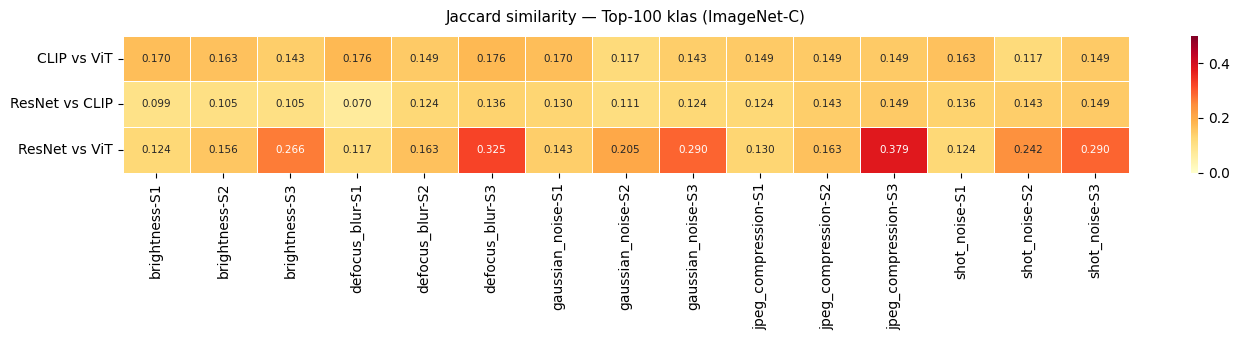

Saved → /content/drive/MyDrive/results/stats/heatmap_jaccard_imagenetc.pdf


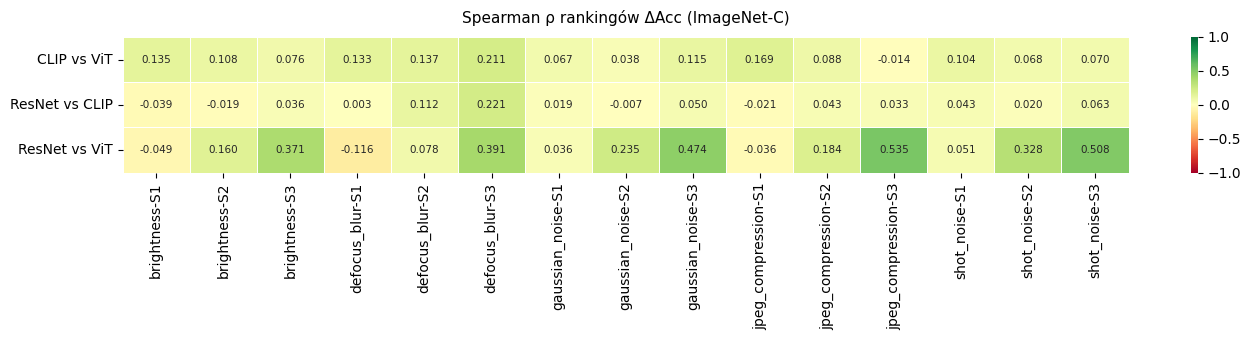

Saved → /content/drive/MyDrive/results/stats/heatmap_spearman_imagenetc.pdf


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

VIZ_COLORS = {"ResNet vs CLIP": "#4C7AB0",
              "ResNet vs ViT":  "#B05A4C",
              "CLIP vs ViT":    "#4CB07A"}

if not df_1B.empty:
    pivot_j = df_1B.pivot_table(
        index="Para", columns=["Corruption", "Severity"], values="Jaccard"
    )
    fig, ax = plt.subplots(figsize=(14, 3.5))
    sns.heatmap(pivot_j, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.4, ax=ax, vmin=0, vmax=0.5,
                annot_kws={"fontsize": 7.5})
    ax.set_title(f"Jaccard similarity — Top-{TOP_N} klas (ImageNet-C)",
                 fontsize=11, pad=10)
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.tight_layout()
    out = os.path.join(STAT_DIR, "heatmap_jaccard_imagenetc.pdf")
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved → {out}")

if not df_2B.empty:
    pivot_s = df_2B.pivot_table(
        index="Para", columns=["Corruption", "Severity"], values="Spearman_rho"
    )
    fig, ax = plt.subplots(figsize=(14, 3.5))
    sns.heatmap(pivot_s, annot=True, fmt=".3f", cmap="RdYlGn",
                linewidths=0.4, ax=ax, vmin=-1, vmax=1,
                annot_kws={"fontsize": 7.5}, center=0)
    ax.set_title("Spearman ρ rankingów ΔAcc (ImageNet-C)",
                 fontsize=11, pad=10)
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.tight_layout()
    out = os.path.join(STAT_DIR, "heatmap_spearman_imagenetc.pdf")
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved → {out}")